### Liberaries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### Helper Functions

In [3]:
def func():
    return 0

In [4]:
#defind varaibles

n_parts = 10000
T = 5
dt = 0.01
n_steps = int(T/ dt)
epsilon = np.sqrt(dt)

#set the boundries
bc_1 = 0
bc_2 = 1

#drift and diffusion coefficents
sigma  = 1
b = 2

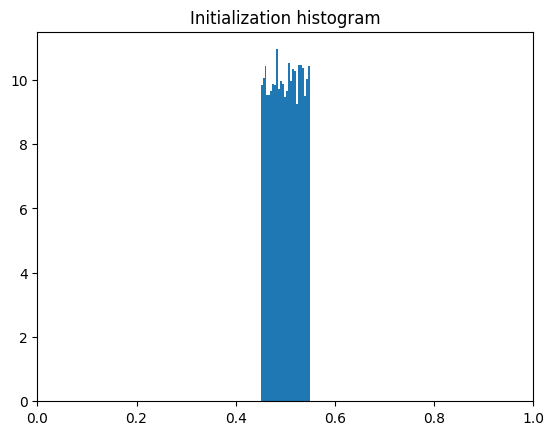

In [5]:

# intial value of the particles
# X_0 = np.random.uniform(bc_1,bc_2, n_parts)
X_0 = np.random.uniform(.45,.55, n_parts)

plt.hist(X_0, bins=25, density=True)
plt.title("Initialization histogram")
plt.xlim((bc_1, bc_2))
plt.show()


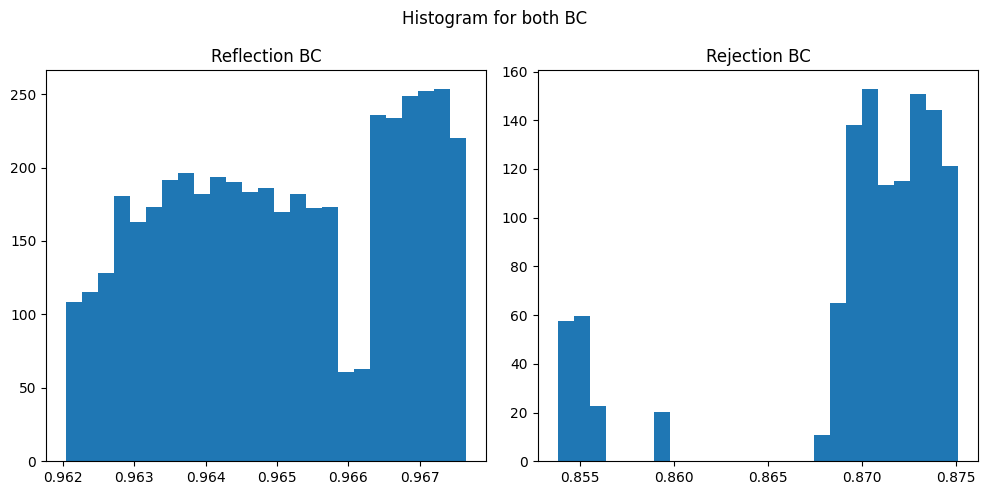

/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


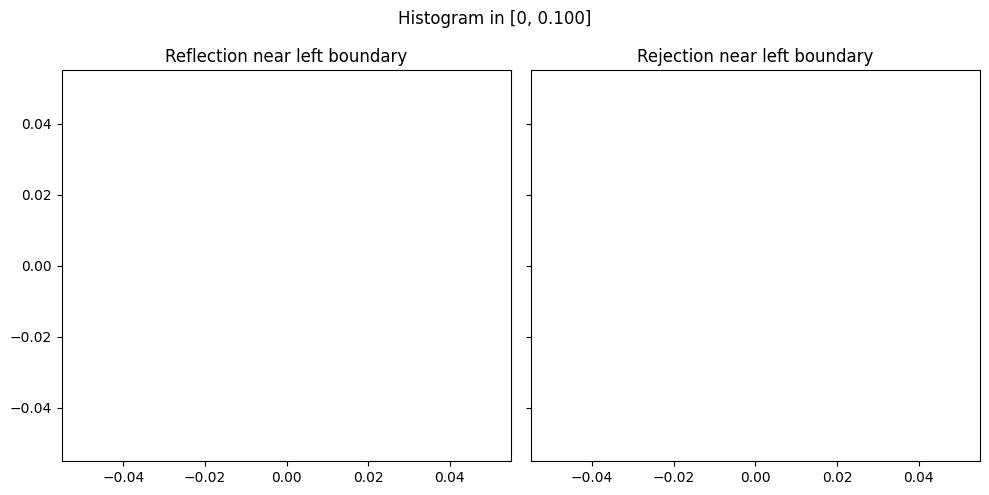

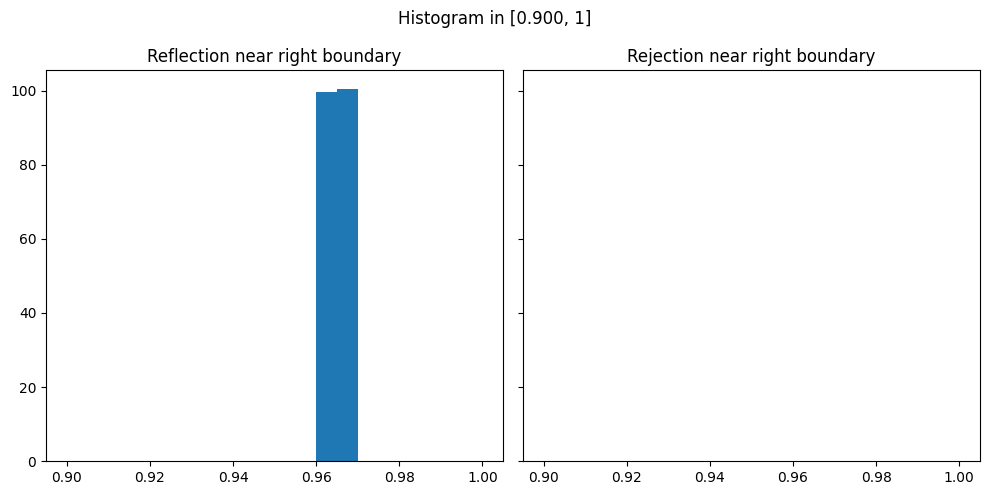

In [7]:


# solution array with inital value
X_ref = np.zeros(n_parts)
X_rej = np.zeros(n_parts)

X_ref = np.copy(X_0)
X_rej = np.copy(X_0)



#precompute xi values
xi = np.random.normal(0,1, (n_steps,n_parts))

# this was just test for uniform instead of normal, same result as the theory
# xi = np.random.uniform(-1,1, (n_steps,n_parts)) 


# fig, ax = plt.subplots(1, 2, figsize=(10, 5))

#time step
for i in range(n_steps):

    # xi = newRandom()

    xi = np.random.normal(0,1)

    X_ref = X_ref +  b*dt + epsilon*sigma* xi
    
    selection1 = X_ref < bc_1
    selection2 = X_ref > bc_2

    X_ref[selection1] = 2*bc_1 - X_ref[selection1]
    X_ref[selection2] = 2*bc_2 - X_ref[selection2]

    
    #do the same but for rejection


    proposed = X_rej+  b* dt + epsilon*sigma* xi

    selection = (proposed < bc_1) | (proposed > bc_2)
    X_rej[~selection] = proposed[~selection]


    
# plot full histogram
fig, ax = plt.subplots(1, 2, figsize=(10, 5))


ax[0].set_title("Reflection BC")
ax[0].hist(X_ref, bins=25, density=True)

ax[1].set_title("Rejection BC")
ax[1].hist(X_rej, bins=25, density=True)


fig.suptitle("Histogram for both BC")
plt.tight_layout()
plt.show()



# inspect x in rand of width next to boundry
width = epsilon #0.1

bins = np.linspace(bc_1, bc_1 + width, 21)
X_ref_bl1 = X_ref[X_ref <= bc_1 + width]
X_rej_bl1 = X_rej[X_rej <= bc_1 + width]

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].hist(X_ref_bl1, bins=bins, density=True)
ax[0].set_title("Reflection near left boundary")

ax[1].hist(X_rej_bl1, bins=bins, density=True)
ax[1].set_title("Rejection near left boundary")

fig.suptitle(f"Histogram in [{bc_1}, {bc_1+width:.3f}]")
plt.tight_layout()
plt.show()


bins = np.linspace(bc_2- width, bc_2, 21)
X_ref_bl2 = X_ref[X_ref >= bc_2 - width]
X_rej_bl2 = X_rej[X_rej >= bc_2 - width]

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].hist(X_ref_bl2, bins=bins, density=True)
ax[0].set_title("Reflection near right boundary")

ax[1].hist(X_rej_bl2, bins=bins, density=True)
ax[1].set_title("Rejection near right boundary")

fig.suptitle(f"Histogram in [{bc_2-width:.3f}, {bc_2}]")
plt.tight_layout()
plt.show()
    
